# Week 1 class

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/goodman-imperial/discrete-maths-classes/blob/main/week-1-class.ipynb)

The aim of this class is to implement the Fibonacci algorithm using the following methods, and plot their timings (for $n=1$ to 100, except for the recursive algorithm where you should stop at $n=30$):

* Recursive
* Table
* Keep last two values
* Analytic (if you have time)
* Matrix (if you have time)

## Python

You can use any language you like, but I'll use Python for all my code samples and during the class. I think Python is very simple syntactically so the code samples should be easy enough to follow even if you don't know Python. On the other hand, I would strongly encourage you to learn it as it's an incredibly useful language. Here is a nice tutorial on Python, NumPy (numerical library for efficient array computation) and Jupyter (the notebook interface I'm using here):

* [Python Numpy Jupyter tutorial](https://cs231n.github.io/python-numpy-tutorial/)

Here is a little sample of plotting timings for a function in Python.

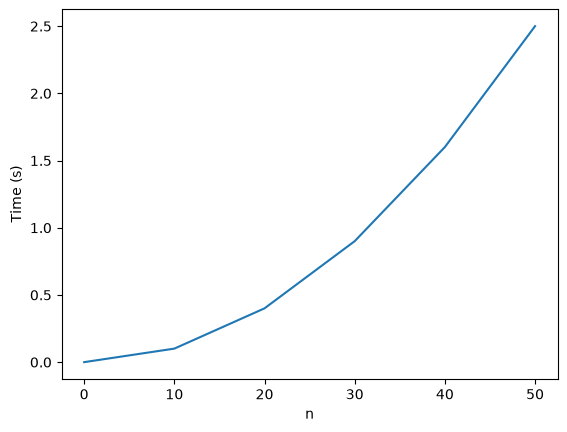

In [1]:
# this first line is just used to make the plots appear nicely in the notebook
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import time

def fake_function(n):
    time.sleep(0.001*n*n)
    
def timeit(n):
    start = time.time()
    fake_function(n)
    end = time.time()
    return end-start
    
N = [0, 10, 20, 30, 40, 50]
T = [timeit(n) for n in N]
plt.plot(N, T)
plt.xlabel('n')
plt.ylabel('Time (s)');

## Implementation notes on compiled languages

For the other ones, if you're using a compiled language, they might run so fast that in order to time them you should slow down the addition by adding a 1 microsecond wait. I've included a C++ ``busy_sleep`` function below to do that.

```c++
#include <chrono>
#include <iostream>
#include <fstream>

using namespace std;

// this function busy sleeps for n microseconds
void busy_sleep(int n)
{
    auto start = chrono::steady_clock::now();
    while(chrono::duration_cast<chrono::microseconds>(chrono::steady_clock::now() - start).count()<n) {};
}
```

## Tasks
### 1. Recursive

Text(0, 0.5, 'Time (s)')

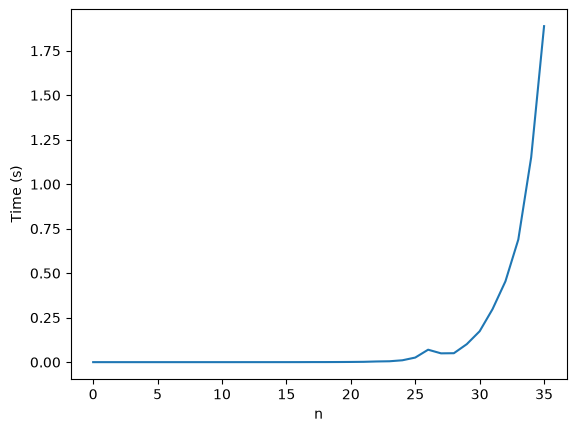

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import time

def F(n):
    if(n < 2):
        return 1
    else:
        return F(n-1) + F(n-2)
    
def timeit(n):
    start = time.time()
    F(n)
    end = time.time()
    return end-start
    
N = list(range(0, 36))
T = [timeit(n) for n in N]
plt.plot(N, T)
plt.xlabel('n')
plt.ylabel('Time (s)')

### 2. Table

Text(0, 0.5, 'Time (s)')

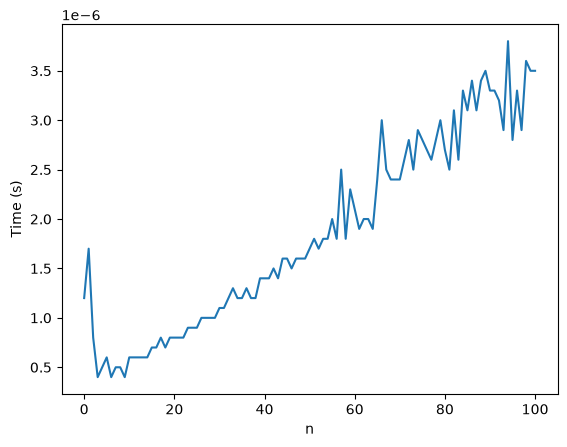

In [20]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import time

def F(n):
    fib = [0] * n

    for i in fib:
        if i < 2:
            fib[i] = 1
        else:
            fib[i] = fib[i - 1] + fib[i - 2]
    

def timeit(n):
    start = time.perf_counter()
    F(n)
    end = time.perf_counter()
    return end-start
    
N = list(range(0, 101))
T = [timeit(n) for n in N]
plt.plot(N, T)
plt.xlabel('n')
plt.ylabel('Time (s)')

### 3. Keep last two values

Text(0, 0.5, 'Time (s)')

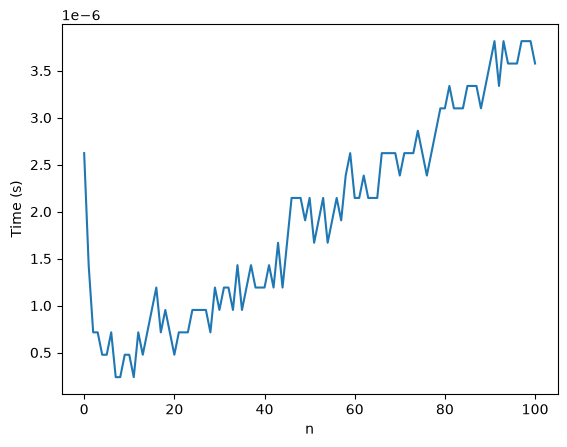

In [10]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import time

def F(n):
    a = b = 1

    for i in range(3, n + 1):
        a, b = b, a + b
    return b

def timeit(n):
    start = time.time()
    F(n)
    end = time.time()
    return end-start
    
N = list(range(0, 101))
T = [timeit(n) for n in N]
plt.plot(N, T)
plt.xlabel('n')
plt.ylabel('Time (s)')

*Note that the code below uses the same "keep last two values algorithms" but with `perf_counter()` instead of `time()` to reduce noise*

Text(0, 0.5, 'Time (s)')

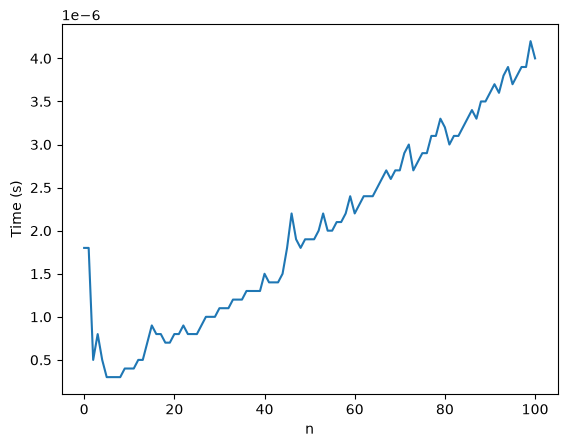

In [16]:
# This uses perf_counter to reduce noise in graph
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import time

def F(n):
    a = b = 1

    for _ in range(3, n + 1):
        a, b = b, a + b
    return b

def timeit(n):
    start = time.perf_counter()
    F(n)
    end = time.perf_counter()
    return end - start
    
N = list(range(0, 101))
T = [timeit(n) for n in N]
plt.plot(N, T)
plt.xlabel('n')
plt.ylabel('Time (s)')

### 4. Analytic
*This is the constant time method so the expected graph should be flat approximately*

Text(0, 0.5, 'Time (s)')

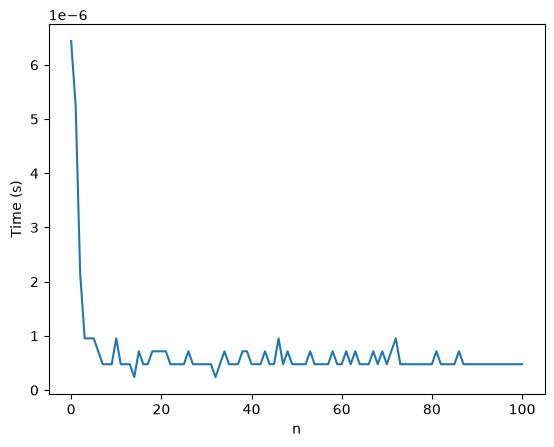

In [22]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import time
from math import sqrt

def F(n):
    phi = (1 + sqrt(5))/2

    return (phi**(n) - (1 - phi)**n)/sqrt(5)

def timeit(n):
    start = time.time()
    F(n)
    end = time.time()
    return end-start
    
N = list(range(0, 101))
T = [timeit(n) for n in N]
plt.plot(N, T)
plt.xlabel('n')
plt.ylabel('Time (s)')

### 5. Matrix Method

Text(0, 0.5, 'Time (s)')

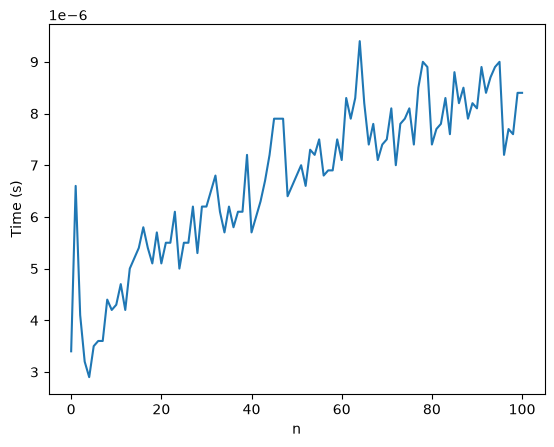

In [39]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import time

def mat_mult(A, B):
    return [[A[0][0]*B[0][0] + A[0][1]*B[1][0], A[0][0]*B[0][1] + A[0][1]*B[1][1]],
            [A[1][0]*B[0][0] + A[1][1]*B[1][0], A[1][0]*B[0][1] + A[1][1]*B[1][1]]]

def mat_pow(mat, n):
    result = [[1, 0], [0, 1]]

    while(n > 0):
        if(n % 2 == 1):
            result = mat_mult(result, mat)
        
        mat = mat_mult(mat, mat)
        n = n // 2
    return result

def F(n):
    return mat_pow([[1, 1], [1, 0]], n)[0][1]

def timeit(n):
    start = time.perf_counter()
    F(n)
    end = time.perf_counter()
    return end-start
    
N = list(range(0, 101))
T = [timeit(n) for n in N]
plt.plot(N, T)
plt.xlabel('n')
plt.ylabel('Time (s)')